# Map & Path Visualization
Đầu vào: file obstacle grid `.txt`, radiation grid `.txt`, và path dạng list của tuple `(row, col)`.

In [8]:
# import numpy as np
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches
# from matplotlib.colors import ListedColormap
# from pathlib import Path

# # ─────────────────────────────────────────
# # CẤU HÌNH ĐẦU VÀO  (chỉnh tại đây)
# # ─────────────────────────────────────────
# OBSTACLE_FILE  = "data/maps/mixed200/mixed200.txt"
# RADIATION_FILE = "data/maps/mixed200/radiation_grid.txt"
# CONFIG_FILE    = "configs/scenario_custom_200x200.yaml"

# # OBSTACLE_FILE  = "data/maps/triangle300/triangle300.txt"
# # RADIATION_FILE = "data/maps/triangle300/radiation_grid_triangle300.txt"
# # CONFIG_FILE    = "configs/scenario_triangle_300_lowrisk.yaml"

# SAVE_PATH       = None   # None = chỉ hiển thị; đặt đường dẫn .png để lưu
# SHOW_GRID_LINES = True   # kẻ ô lưới
# RI_MAX          = 8.0    # ngưỡng phân loại high risk

# # ─────────────────────────────────────────
# # ĐỌC PATH TỪ route_summary.json (tuỳ chọn)
# # ─────────────────────────────────────────
# import json as _json

# JSON_FILE = "results/mixed_200_lowrisk/paths/route_summary.json"
# try:
#     with open(JSON_FILE) as f:
#         data = _json.load(f)
#     path_from_json = [tuple(p) for p in data["full_path"]]
#     print(f"Path từ JSON: {len(path_from_json)} steps")
# except FileNotFoundError:
#     print(f"[Bỏ qua] File chưa có: {JSON_FILE}")
#     path_from_json = []
#     data = {}

# # ─────────────────────────────────────────
# # PATH FMF
# # ─────────────────────────────────────────
# # FMF_SMOOTH: chọn loại path muốn load từ JSON
# #   True  → turning points (~128 bước, path đã smooth)
# #   False → cell-by-cell  (~1295 bước, full path)
# #   None  → lấy run MỚI NHẤT (bất kể smooth hay không)
# #
# # LƯU Ý: tất cả run đều có best_cost giống nhau (cost OR-Tools TSP
# # không phụ thuộc smooth), nên KHÔNG dùng min(best_cost) để chọn run.
# FMF_SMOOTH = True   # ← chỉnh tại đây: True / False / None

# JSON_FILE_FMF = "E:\\last_dance\\LastDance\\FMF\\results\\mixed200.json"

# # JSON_FILE_FMF = "E:\\last_dance\\LastDance\\FMF\\results\\mixed200.json"
# try:
#     with open(JSON_FILE_FMF) as f:
#         data_fmf = _json.load(f)

#     runs = data_fmf["runs"]

#     if FMF_SMOOTH is None:
#         # Lấy run mới nhất
#         chosen_run = runs[-1]
#         print(f"[FMF] Chọn run MỚI NHẤT (index {len(runs)-1})")
#     else:
#         # Lọc các run có đúng smooth setting
#         matched = [r for r in runs
#                    if r.get("config", {}).get("smooth") == FMF_SMOOTH]
#         if matched:
#             # Trong các run khớp, lấy run mới nhất (cuối list)
#             chosen_run = matched[-1]
#             print(f"[FMF] Chọn run smooth={FMF_SMOOTH} mới nhất "
#                   f"(index {runs.index(chosen_run)}/{len(runs)-1})")
#         else:
#             # Fallback: run mới nhất
#             chosen_run = runs[-1]
#             print(f"[FMF] Không tìm thấy run smooth={FMF_SMOOTH}, "
#                   f"dùng run mới nhất (index {len(runs)-1})")

#     path_from_fmf = [tuple(p) for p in chosen_run["path"]]
#     cfg = chosen_run.get("config", {})
#     print(f"Path từ FMF: {len(path_from_fmf)} steps  "
#           f"(smooth={cfg.get('smooth','?')}, "
#           f"best_cost={chosen_run['summary']['best_cost']})")

# except FileNotFoundError:
#     print(f"[Bỏ qua] File chưa có: {JSON_FILE_FMF}")
#     path_from_fmf = []
#     data_fmf = {}

# PATH = path_from_fmf  # hoặc path_from_json nếu có
# print(f"PATH: {len(PATH)} bước")

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
from pathlib import Path

# ─────────────────────────────────────────
# CẤU HÌNH ĐẦU VÀO  (chỉnh tại đây)
# ─────────────────────────────────────────
# OBSTACLE_FILE  = "data/maps/mixed200/mixed200.txt"
# RADIATION_FILE = "data/maps/mixed200/radiation_grid.txt"
# CONFIG_FILE    = "configs/scenario_custom_200x200.yaml"

# OBSTACLE_FILE  = "data/maps/triangle300/triangle300.txt"
# RADIATION_FILE = "data/maps/triangle300/radiation_grid_triangle300.txt"
# CONFIG_FILE    = "configs/scenario_triangle_300_lowrisk.yaml"

# OBSTACLE_FILE = "data/scenario5/scenario5_grid.txt"
# RADIATION_FILE = "data/scenario5/radiation_grid.txt"
# CONFIG_FILE = "configs/scenario5.yaml"

OBSTACLE_FILE = "data/scenario5/scenario5_grid.txt"
RADIATION_FILE = "data/scenario5/radiation_grid.txt"
CONFIG_FILE = "configs/scenario5.yaml"

SAVE_PATH       = None   # None = chỉ hiển thị; đặt đường dẫn .png để lưu
SHOW_GRID_LINES = True   # kẻ ô lưới
RI_MAX          = 8.0    # ngưỡng phân loại high risk

# ─────────────────────────────────────────
# ĐỌC PATH TỪ route_summary.json (tuỳ chọn)
# ─────────────────────────────────────────
import json as _json

# JSON_FILE = "results/mixed_200_lowrisk/paths/route_summary.json"

JSON_FILE = "results/scenario5/paths/route_summary.json"
try:
    with open(JSON_FILE) as f:
        data = _json.load(f)
    path_from_json = [tuple(p) for p in data["full_path"]]
    print(f"Path từ JSON: {len(path_from_json)} steps")
except FileNotFoundError:
    print(f"[Bỏ qua] File chưa có: {JSON_FILE}")
    path_from_json = []
    data = {}

# ─────────────────────────────────────────
# PATH FMF
# ─────────────────────────────────────────
# FMF_SMOOTH: chọn loại path muốn load từ JSON
#   True  → turning points (~128 bước, path đã smooth)
#   False → cell-by-cell  (~1295 bước, full path)
#   None  → lấy run MỚI NHẤT (bất kể smooth hay không)
#
# LƯU Ý: tất cả run đều có best_cost giống nhau (cost OR-Tools TSP
# không phụ thuộc smooth), nên KHÔNG dùng min(best_cost) để chọn run.
FMF_SMOOTH = True   # ← chỉnh tại đây: True / False / None

JSON_FILE_FMF = "E:\\last_dance\\LastDance\\FMF\\results\\scenario5_grid.json"


def _fmf_best_cost(run):
    """Đọc best TSP cost từ cả format cũ và mới của summary."""
    summary = run.get("summary", {})
    if "best_cost" in summary:                       # format cũ
        return summary["best_cost"]
    tsp = summary.get("tsp_cost")                    # format mới
    if isinstance(tsp, dict) and "best" in tsp:
        return tsp["best"]
    return None


# JSON_FILE_FMF = "E:\\last_dance\\LastDance\\FMF\\results\\mixed200.json"
try:
    with open(JSON_FILE_FMF) as f:
        data_fmf = _json.load(f)

    runs = data_fmf["runs"]

    if FMF_SMOOTH is None:
        # Lấy run mới nhất
        chosen_run = runs[-1]
        print(f"[FMF] Chọn run MỚI NHẤT (index {len(runs)-1})")
    else:
        # Lọc các run có đúng smooth setting
        matched = [r for r in runs
                   if r.get("config", {}).get("smooth") == FMF_SMOOTH]
        if matched:
            # Trong các run khớp, lấy run mới nhất (cuối list)
            chosen_run = matched[-1]
            print(f"[FMF] Chọn run smooth={FMF_SMOOTH} mới nhất "
                  f"(index {runs.index(chosen_run)}/{len(runs)-1})")
        else:
            # Fallback: run mới nhất
            chosen_run = runs[-1]
            print(f"[FMF] Không tìm thấy run smooth={FMF_SMOOTH}, "
                  f"dùng run mới nhất (index {len(runs)-1})")

    path_from_fmf = [tuple(p) for p in chosen_run["path"]]
    cfg = chosen_run.get("config", {})
    best_cost = _fmf_best_cost(chosen_run)
    best_cost_str = f"{best_cost:.4f}" if isinstance(best_cost, (int, float)) else "N/A"
    print(f"Path từ FMF: {len(path_from_fmf)} steps  "
          f"(smooth={cfg.get('smooth','?')}, "
          f"best_cost={best_cost_str})")

except FileNotFoundError:
    print(f"[Bỏ qua] File chưa có: {JSON_FILE_FMF}")
    path_from_fmf = []
    data_fmf = {}

#PATH = path_from_fmf  # hoặc path_from_json nếu có
PATH = [(4, 6), (5, 5), (6, 5), (7, 5), (8, 6), (8, 7), (9, 8), (10, 8), (10, 8), (10, 9), (10, 10), (11, 11), (12, 12), (12, 13), (12, 14), (12, 14), (13, 15), (14, 15), (15, 15), (16, 15), (17, 15), (18, 15), (19, 15), (20, 15), (21, 15), (21, 15), (22, 15), (23, 15), (24, 15), (25, 15), (26, 15), (27, 15), (28, 15), (29, 15), (29, 15), (30, 15), (31, 15), (32, 16), (32, 17), (32, 18), (33, 19), (33, 20), (34, 21), (35, 21), (36, 20), (36, 20), (35, 21), (35, 22), (35, 23), (34, 24), (33, 25), (32, 26), (31, 27), (30, 28), (29, 29), (29, 29), (28, 29), (27, 29), (26, 28), (25, 27), (24, 26), (24, 25), (24, 24), (24, 23), (24, 23), (23, 24), (22, 24), (21, 24), (20, 23), (19, 22), (19, 22), (18, 23), (17, 24), (16, 24), (15, 24), (14, 25), (13, 24), (12, 24), (11, 24), (11, 24), (10, 24), (9, 24), (8, 23), (7, 22), (6, 21), (5, 20), (4, 19), (4, 18), (4, 17), (4, 17), (4, 18), (4, 19), (4, 20), (4, 21), (4, 22), (4, 23), (4, 24), (5, 25), (5, 26), (5, 27), (5, 27), (6, 28), (7, 28), (8, 29), (9, 30), (9, 30), (8, 29), (7, 28), (6, 28), (5, 27), (5, 27), (5, 28), (4, 29), (3, 30), (3, 31), (3, 32), (3, 33), (3, 34), (3, 35), (3, 36), (4, 37), (4, 38), (4, 38), (4, 39), (4, 40), (4, 41), (4, 42), (4, 43), (4, 43), (5, 43), (6, 44), (7, 44), (8, 44), (9, 44), (10, 44), (11, 44), (12, 44), (13, 43), (14, 42), (14, 41), (14, 41), (15, 40), (16, 40), (17, 40), (18, 39), (19, 38), (20, 38), (21, 38), (22, 37), (22, 36), (22, 36), (23, 37), (24, 38), (24, 39), (24, 40), (25, 41), (25, 42), (25, 43), (25, 44), (25, 45), (25, 45), (25, 44), (25, 43), (25, 42), (26, 41), (27, 40), (28, 40), (29, 40), (30, 39), (31, 38), (31, 38), (31, 39), (31, 40), (31, 41), (32, 42), (32, 43), (32, 44), (32, 45), (32, 45), (33, 45), (34, 45), (35, 45), (36, 46), (37, 46), (37, 46), (38, 47), (39, 47), (40, 47), (41, 47), (42, 47), (43, 47), (44, 47), (45, 47), (46, 47), (46, 47), (46, 46), (45, 45), (45, 44), (45, 43), (44, 42), (43, 41), (43, 40), (43, 40), (44, 40), (45, 41), (46, 40), (46, 39), (46, 38), (46, 37), (46, 36), (46, 35), (46, 34), (45, 33), (44, 32), (43, 32), (42, 32), (42, 32), (43, 31), (44, 30), (45, 29), (46, 28), (46, 27), (46, 27), (46, 26), (46, 25), (46, 24), (46, 23), (46, 22), (46, 21), (46, 20), (46, 19), (46, 18), (46, 17), (46, 16), (46, 16), (45, 16), (44, 16), (43, 15), (42, 14), (41, 14), (41, 14), (41, 13), (41, 12), (40, 11), (39, 10), (38, 10), (37, 10), (37, 10), (38, 11), (39, 11), (40, 11), (41, 10), (42, 9), (43, 8), (43, 7), (43, 6), (43, 5), (43, 5), (42, 4), (41, 4), (40, 3), (39, 3), (38, 2), (37, 2), (36, 2), (35, 2), (34, 3), (33, 3), (32, 4), (32, 4), (32, 3), (32, 2), (31, 1), (30, 1), (29, 1), (28, 1), (27, 2), (26, 2), (25, 3), (24, 4), (23, 5), (22, 6), (22, 7), (22, 7), (21, 6), (20, 6), (19, 5), (18, 5), (17, 4), (16, 3), (15, 2), (14, 3), (13, 3), (13, 3), (12, 2), (11, 1), (10, 1), (9, 1), (8, 1), (7, 2), (6, 3), (5, 4), (4, 5), (4, 6)]
print(f"PATH: {len(PATH)} bước")

Path từ JSON: 276 steps
[FMF] Chọn run smooth=True mới nhất (index 2/4)
Path từ FMF: 92 steps  (smooth=True, best_cost=395.2457)
PATH: 304 bước


In [10]:
# ─────────────────────────────────────────
# ĐỌC FILE
# ─────────────────────────────────────────
def load_txt(path, dtype=float):
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append([dtype(x) for x in line.split()])
    return np.array(rows, dtype=dtype)

obstacle  = load_txt(OBSTACLE_FILE,  dtype=int)
radiation = load_txt(RADIATION_FILE, dtype=float)

assert obstacle.shape == radiation.shape, "Grid size mismatch!"
nrows, ncols = obstacle.shape
print(f"Map size: {nrows} × {ncols}")
print(f"Targets (value 2): {(obstacle == 2).sum()}")
print(f"Obstacles (value 1): {(obstacle == 1).sum()}")
print(f"Radiation max: {radiation.max():.2f}, cells > ri_max: {(radiation > RI_MAX).sum()}")
print(f"Path steps: {len(PATH)}")

Map size: 50 × 50
Targets (value 2): 32
Obstacles (value 1): 293
Radiation max: 15.08, cells > ri_max: 99
Path steps: 304


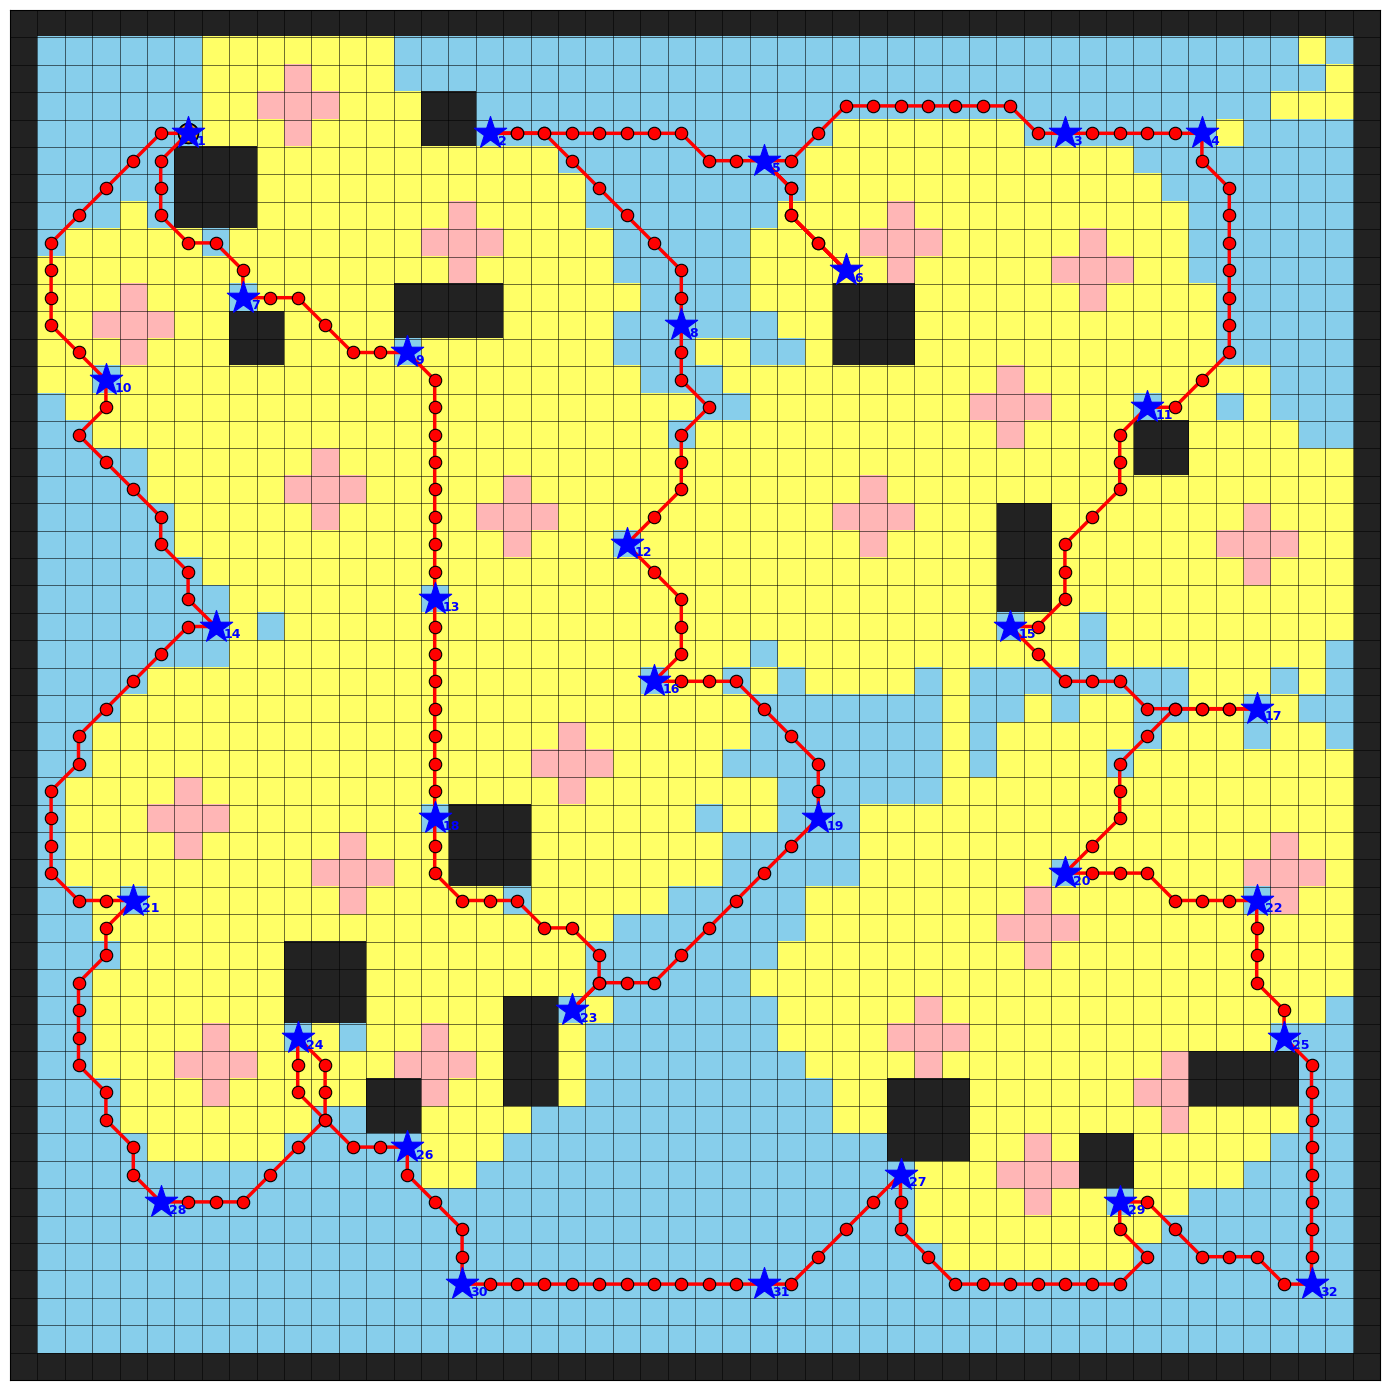

In [11]:
# ─────────────────────────────────────────
# VẼ BẢN ĐỒ + ĐƯỜNG ĐI
# ─────────────────────────────────────────
LOW_THRESH  = 0.5
HIGH_THRESH = RI_MAX

# Phân loại từng ô: 0=obstacle, 1=low, 2=medium, 3=high risk
base = np.ones_like(obstacle, dtype=int)          # default: low risk
base[radiation >= LOW_THRESH]  = 2                # medium risk (vàng)
base[radiation >= HIGH_THRESH] = 3                # high risk  (hồng)
base[obstacle == 1]            = 0                # obstacle   (đen)

cmap = ListedColormap([
    "#222222",  # 0: obstacle
    "#87CEEB",  # 1: low risk  – sky blue
    "#FFFF66",  # 2: med risk  – vàng
    "#FFB6B6",  # 3: high risk – hồng
])

fig_w = max(10, ncols * 0.28)
fig_h = max(8,  nrows * 0.28)
fig, ax = plt.subplots(figsize=(fig_w, fig_h))

# --- nền bản đồ ---
ax.imshow(base, cmap=cmap, vmin=0, vmax=3,
          origin="upper", interpolation="nearest")

# --- đường đi ---
if PATH:
    xs = [p[1] for p in PATH]
    ys = [p[0] for p in PATH]
    ax.plot(xs, ys, color="red", linewidth=2.5, zorder=4)
    ax.scatter(xs, ys, s=80, c="red", edgecolors="black",
               linewidths=0.8, zorder=5)
    # điểm bắt đầu = xanh lá, điểm kết thúc = cam
    ax.scatter(xs[0],  ys[0],  s=200, c="lime",   edgecolors="black",
               linewidths=1.2, zorder=6, marker="o")
    ax.scatter(xs[-1], ys[-1], s=200, c="orange", edgecolors="black",
               linewidths=1.2, zorder=6, marker="o")

# --- targets (ngôi sao xanh) ---
target_pos = np.argwhere(obstacle == 2)
for idx, (r, c) in enumerate(target_pos, start=1):
    ax.scatter(c, r, marker="*", s=600, c="blue",
               edgecolors="blue", linewidths=0.8, zorder=8)
    ax.text(c + 0.3, r + 0.3, str(idx),
            color="blue", fontsize=9, fontweight="bold",
            ha="left", va="center", zorder=9)

# --- lưới ô ---
if SHOW_GRID_LINES:
    ax.set_xticks(np.arange(-0.5, ncols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, nrows, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="both", bottom=False, left=False,
                   labelbottom=False, labelleft=False)

ax.set_xlim(-0.5, ncols - 0.5)
ax.set_ylim(nrows - 0.5, -0.5)
ax.set_aspect("equal")

# --- legend ---
# legend_items = [
#     mpatches.Patch(color="#222222", label="Obstacle"),
#     mpatches.Patch(color="#87CEEB", label="Low risk"),
#     mpatches.Patch(color="#FFFF66", label="Medium risk"),
#     mpatches.Patch(color="#FFB6B6", label="High risk"),
#     plt.Line2D([0],[0], color="red",  linewidth=2, label="Path"),
#     plt.Line2D([0],[0], marker="*",   color="blue", linestyle="None",
#                markersize=10, label="Target"),
#     plt.Line2D([0],[0], marker="o",   color="lime", linestyle="None",
#                markersize=8, label="Start"),
#     plt.Line2D([0],[0], marker="o",   color="orange", linestyle="None",
#                markersize=8, label="End"),
# ]
# ax.legend(handles=legend_items, loc="upper right",
#           fontsize=8, framealpha=0.85)

fig.tight_layout()

if SAVE_PATH:
    Path(SAVE_PATH).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved: {SAVE_PATH}")

plt.show()

  PATH METRICS  [configs/scenario5.yaml]
  Metric                      ω        Computed       ACO-GA-A*
--------------------------------------------------------------------
  Length        (m)        0.60        312.8356        313.5219
  Risk      (Sv·h)         0.20        415.3548        422.7955
  Energy  (turns)          0.00          0.0000          0.0000
  Collision Risk           0.20         87.0166         87.1925
--------------------------------------------------------------------
  Total Cost                           288.1756        278.4051
  Steps: 304   Unique cells: 260


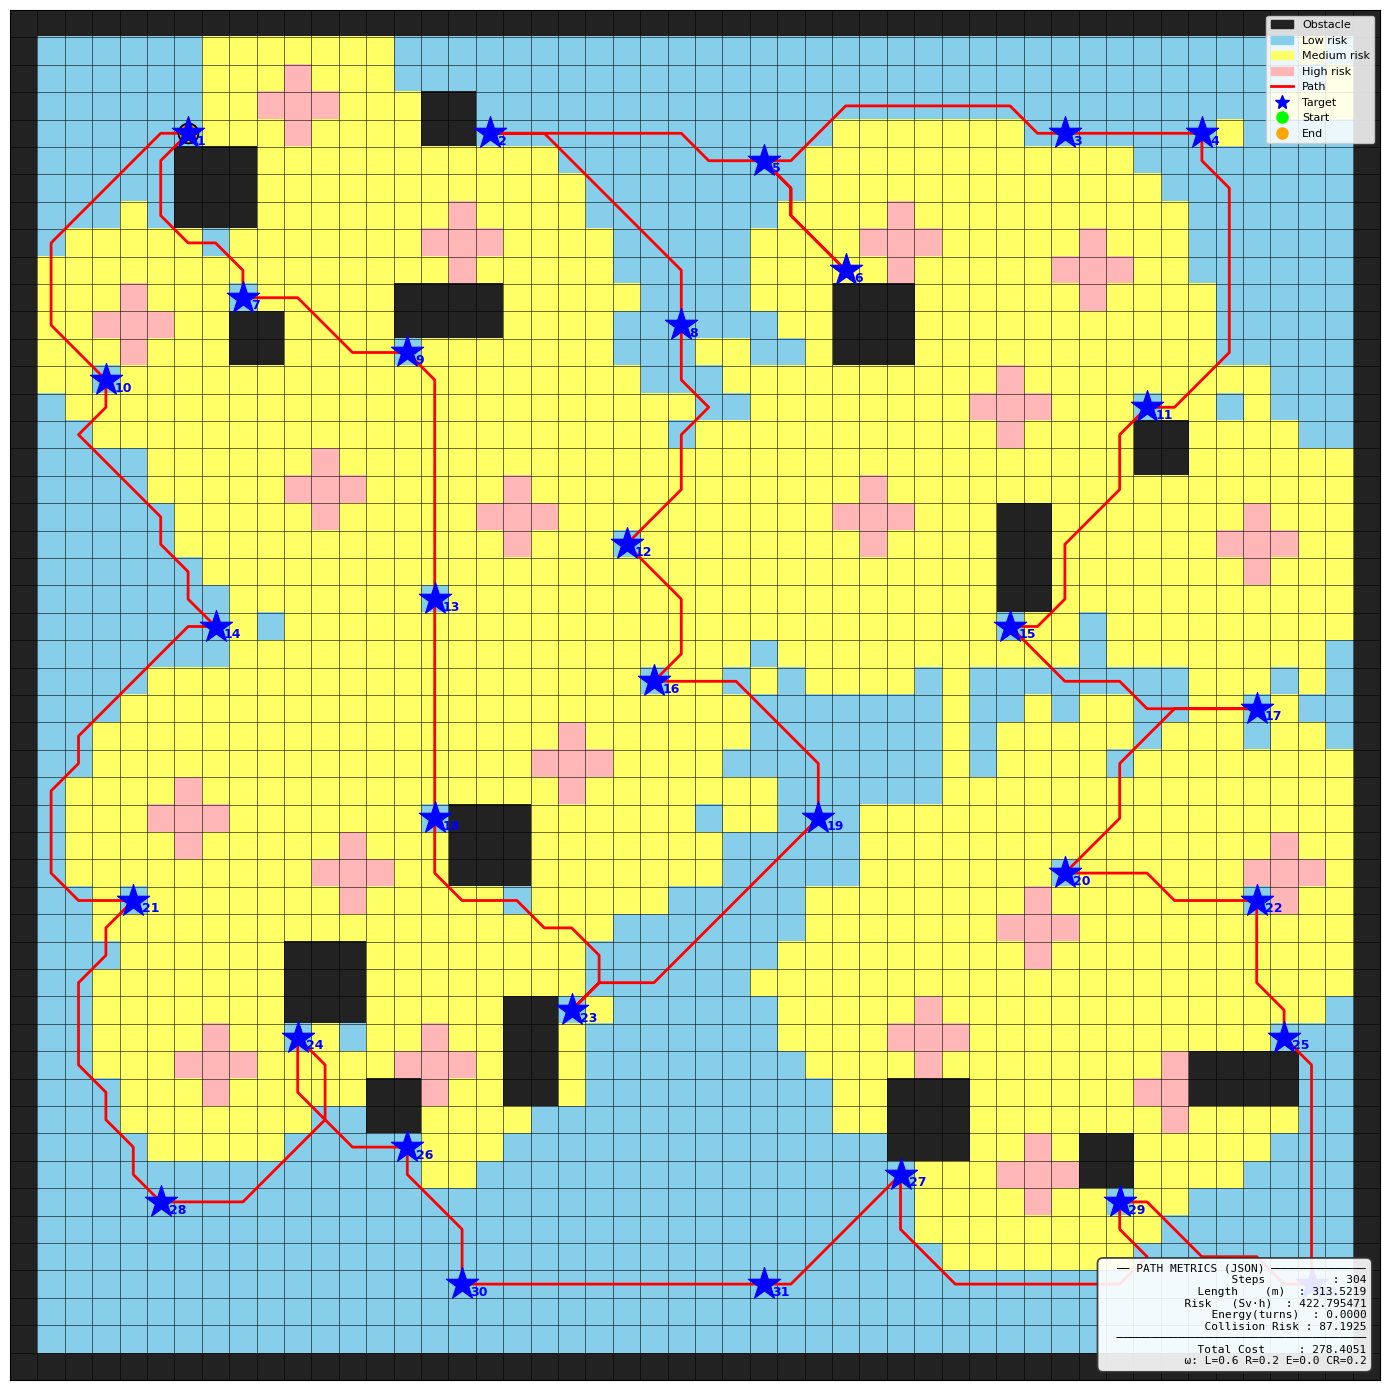

In [12]:
# ═══════════════════════════════════════════════════════════════
# ĐO CHỈ SỐ ĐƯỜNG ĐI  –  import src/costs, tham số từ config
# + VẼ BẢN ĐỒ KÈM TEXT-BOX CHỈ SỐ
# ═══════════════════════════════════════════════════════════════
import sys, os

_PROJECT_ROOT = os.path.abspath(".")
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

from src.utils.io_utils          import load_yaml
from src.environment.map_loader  import load_grid_map
from src.costs.total_cost        import CostWeights, path_cost_components

config   = load_yaml(CONFIG_FILE)
grid_map = load_grid_map(config)
weights  = CostWeights.from_config(config)

# ── Tính tất cả chỉ số ──────────────────────────────────────────
computed_metrics = path_cost_components(grid_map, PATH, weights)
json_metrics     = data.get("full_path_components", {})

# ── Bảng so sánh ────────────────────────────────────────────────
LABELS = {
    "length":         "Length        (m)",
    "risk":           "Risk      (Sv·h)",
    "energy":         "Energy  (turns)",
    "collision_risk": "Collision Risk",
    "total":          "Total Cost",
}
OMEGAS = {
    "length":         weights.omega_length,
    "risk":           weights.omega_risk,
    "energy":         weights.omega_energy,
    "collision_risk": weights.omega_collision_risk,
}

print("=" * 68)
print(f"  PATH METRICS  [{CONFIG_FILE}]")
print("=" * 68)
print(f"  {'Metric':<22}  {'ω':>5}  {'Computed':>14}  {'ACO-GA-A*':>14}")
print("-" * 68)
for key in ["length", "risk", "energy", "collision_risk"]:
    comp = computed_metrics[key]
    jval = json_metrics.get(key)
    j_str = f"{jval:>14.4f}" if isinstance(jval, (int, float)) else f"{'N/A':>14}"
    print(f"  {LABELS[key]:<22}  {OMEGAS[key]:>5.2f}  {comp:>14.4f}  {j_str}")
print("-" * 68)
jt    = json_metrics.get("total")
jt_s  = f"{jt:>14.4f}" if isinstance(jt, (int, float)) else f"{'N/A':>14}"
print(f"  {LABELS['total']:<22}  {'':>5}  {computed_metrics['total']:>14.4f}  {jt_s}")
print("=" * 68)
print(f"  Steps: {len(PATH)}   Unique cells: {len(set(PATH))}")

# ── Vẽ bản đồ + text-box chỉ số ─────────────────────────────────
_obs = grid_map.obstacle_grid
_rad = grid_map.radiation_grid
_nr, _nc = _obs.shape

base = np.ones((_nr, _nc), dtype=int)
base[_rad >= 0.5]            = 2
base[_rad >= grid_map.ri_max] = 3
base[_obs == 1]              = 0

cmap_m = ListedColormap(["#222222", "#87CEEB", "#FFFF66", "#FFB6B6"])
fig, ax = plt.subplots(figsize=(max(12, _nc * 0.28), max(9, _nr * 0.28)))
ax.imshow(base, cmap=cmap_m, vmin=0, vmax=3,
          origin="upper", interpolation="nearest")

if PATH:
    xs = [p[1] for p in PATH]; ys = [p[0] for p in PATH]
    ax.plot(xs, ys, color="red", linewidth=2.0, zorder=4)
    ax.scatter(xs[0],  ys[0],  s=200, c="lime",   edgecolors="black", linewidths=1.2, zorder=6, marker="o")
    ax.scatter(xs[-1], ys[-1], s=200, c="orange", edgecolors="black", linewidths=1.2, zorder=6, marker="o")

for idx, (r, c) in enumerate(np.argwhere(_obs == 2), start=1):
    ax.scatter(c, r, marker="*", s=600, c="blue", edgecolors="blue", linewidths=0.8, zorder=8)
    ax.text(c + 0.3, r + 0.3, str(idx), color="blue", fontsize=9, fontweight="bold",
            ha="left", va="center", zorder=9)

if SHOW_GRID_LINES:
    ax.set_xticks(np.arange(-0.5, _nc, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, _nr, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="both", bottom=False, left=False, labelbottom=False, labelleft=False)

ax.set_xlim(-0.5, _nc - 0.5); ax.set_ylim(_nr - 0.5, -0.5); ax.set_aspect("equal")

# Text-box chỉ số
disp = json_metrics if json_metrics else computed_metrics
src_label = "JSON" if json_metrics else "Computed"
m = computed_metrics
box = "\n".join([
    f"── PATH METRICS ({src_label}) ──────────────",
    f"  Steps          : {len(PATH)}",
    f"  Length    (m)  : {disp.get('length',         m['length']):.4f}",
    f"  Risk   (Sv·h)  : {disp.get('risk',           m['risk']):.6f}",
    f"  Energy(turns)  : {disp.get('energy',         m['energy']):.4f}",
    f"  Collision Risk : {disp.get('collision_risk', m['collision_risk']):.4f}",
    f"  ─────────────────────────────────────",
    f"  Total Cost     : {disp.get('total',          m['total']):.4f}",
    f"  ω: L={weights.omega_length} R={weights.omega_risk} "
    f"E={weights.omega_energy} CR={weights.omega_collision_risk}",
])
ax.text(0.99, 0.01, box, transform=ax.transAxes, fontsize=8, family="monospace",
        va="bottom", ha="right",
        bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                  alpha=0.90, edgecolor="#333333", linewidth=1.3),
        zorder=10)

legend_items = [
    mpatches.Patch(color="#222222", label="Obstacle"),
    mpatches.Patch(color="#87CEEB", label="Low risk"),
    mpatches.Patch(color="#FFFF66", label="Medium risk"),
    mpatches.Patch(color="#FFB6B6", label="High risk"),
    plt.Line2D([0],[0], color="red",    linewidth=2,   label="Path"),
    plt.Line2D([0],[0], marker="*",     color="blue",  linestyle="None", markersize=10, label="Target"),
    plt.Line2D([0],[0], marker="o",     color="lime",  linestyle="None", markersize=8,  label="Start"),
    plt.Line2D([0],[0], marker="o",     color="orange",linestyle="None", markersize=8,  label="End"),
]
ax.legend(handles=legend_items, loc="upper right", fontsize=8, framealpha=0.85)
fig.tight_layout()

SAVE_METRICS_PATH = None
if SAVE_METRICS_PATH:
    Path(SAVE_METRICS_PATH).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(SAVE_METRICS_PATH, dpi=150, bbox_inches="tight")
    print(f"Saved: {SAVE_METRICS_PATH}")

plt.show()

In [13]:
# ─────────────────────────────────────────
# IN PATH RA TEXT
# ─────────────────────────────────────────
print(f"Path ({len(PATH)} steps):")
print(PATH)
print()
print("Từng bước:")
for i, (r, c) in enumerate(PATH):
    cell_type = {
        0: "free",
        1: "obstacle",
        2: "target",
    }.get(obstacle[r, c], "free")
    rad_val = radiation[r, c]
    risk = "high" if rad_val >= RI_MAX else ("med" if rad_val >= 0.5 else "low")
    print(f"  step {i:3d}: ({r:3d}, {c:3d})  cell={cell_type:<8}  radiation={rad_val:.3f}  risk={risk}")

Path (304 steps):
[(4, 6), (5, 5), (6, 5), (7, 5), (8, 6), (8, 7), (9, 8), (10, 8), (10, 8), (10, 9), (10, 10), (11, 11), (12, 12), (12, 13), (12, 14), (12, 14), (13, 15), (14, 15), (15, 15), (16, 15), (17, 15), (18, 15), (19, 15), (20, 15), (21, 15), (21, 15), (22, 15), (23, 15), (24, 15), (25, 15), (26, 15), (27, 15), (28, 15), (29, 15), (29, 15), (30, 15), (31, 15), (32, 16), (32, 17), (32, 18), (33, 19), (33, 20), (34, 21), (35, 21), (36, 20), (36, 20), (35, 21), (35, 22), (35, 23), (34, 24), (33, 25), (32, 26), (31, 27), (30, 28), (29, 29), (29, 29), (28, 29), (27, 29), (26, 28), (25, 27), (24, 26), (24, 25), (24, 24), (24, 23), (24, 23), (23, 24), (22, 24), (21, 24), (20, 23), (19, 22), (19, 22), (18, 23), (17, 24), (16, 24), (15, 24), (14, 25), (13, 24), (12, 24), (11, 24), (11, 24), (10, 24), (9, 24), (8, 23), (7, 22), (6, 21), (5, 20), (4, 19), (4, 18), (4, 17), (4, 17), (4, 18), (4, 19), (4, 20), (4, 21), (4, 22), (4, 23), (4, 24), (5, 25), (5, 26), (5, 27), (5, 27), (6, 28),

In [14]:
# ─────────────────────────────────────────
# ĐỌC PATH TỪ route_summary.json (tuỳ chọn)
# ─────────────────────────────────────────
import json

JSON_FILE = "results/scenario7/paths/route_summary.json"

with open(JSON_FILE) as f:
    data = json.load(f)

path_from_json = [tuple(p) for p in data["full_path"]]
print(f"Path từ JSON: {len(path_from_json)} steps")
print("5 bước đầu:", path_from_json[:5])
print("5 bước cuối:", path_from_json[-5:])

Path từ JSON: 784 steps
5 bước đầu: [(3, 4), (4, 4), (5, 4), (6, 4), (7, 4)]
5 bước cuối: [(1, 8), (1, 7), (1, 6), (2, 5), (3, 4)]
